In [1]:
%load_ext autoreload
%autoreload 2

import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tools.particle_swarm_optimization as pso

warnings.filterwarnings("ignore")


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.7.0
 Built: Apr 15 2024 07:13:33

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



In [2]:
folder_path = os.path.join(os.getcwd(), 'results/potjans_diesmann/')

## Inicialización
#pso.generate_first_population(folder_path, 10)


In [4]:
# Run simulation

# trial, subject = 0, 0
# for trial in range(10):
#     for subject in range(10):

#         if len(pso.get_result(folder_path, trial, subject)) == 0:
#             os.system("python -m src.run_model_busse "+str(trial)+" "+str(subject))

#         if len(pso.get_result(folder_path, trial, subject)) == 0:
#             pso.save_imposed_result(folder_path, trial, subject, [0, 0, 0, 0])
    
#     if trial < 10:
#         pso.generate_next_iteration(folder_path, trial)



              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.7.0
 Built: Apr 15 2024 07:13:33

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.


Aug 13 16:24:47 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.1 ms.
RNG seed: 44
Total number of virtual processes: 1
---------> Creating the model...
---> Creating Microcircuits...
---> Creating networks V1_A...
Data will be written to: /home/samuelmr/Documentos/NEST/canonical_microcircuits/results/potjans_diesmann/20240813162447
  Directory has been created.

Neuron numbers are scaled by a factor of 0.100.
Indegrees are scaled by a factor of 0.100.
  Weights and DC input are adjusted to compensate.

Creating neuronal populations.
Creating recording devices.
  Creating spike recorders.
  Creating thalamic multimeters.
Cre

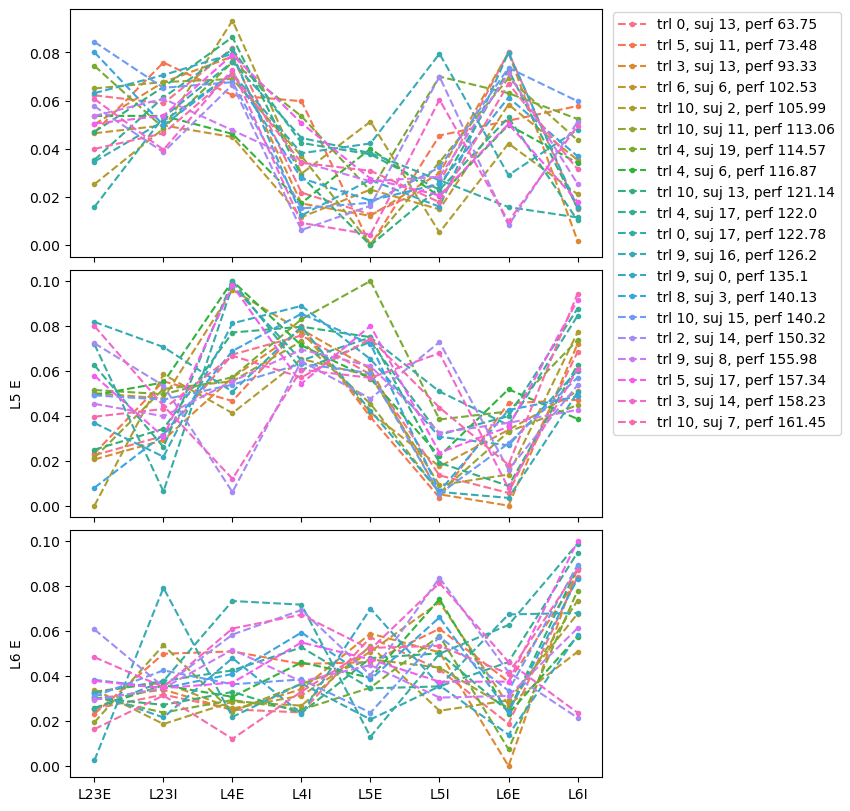

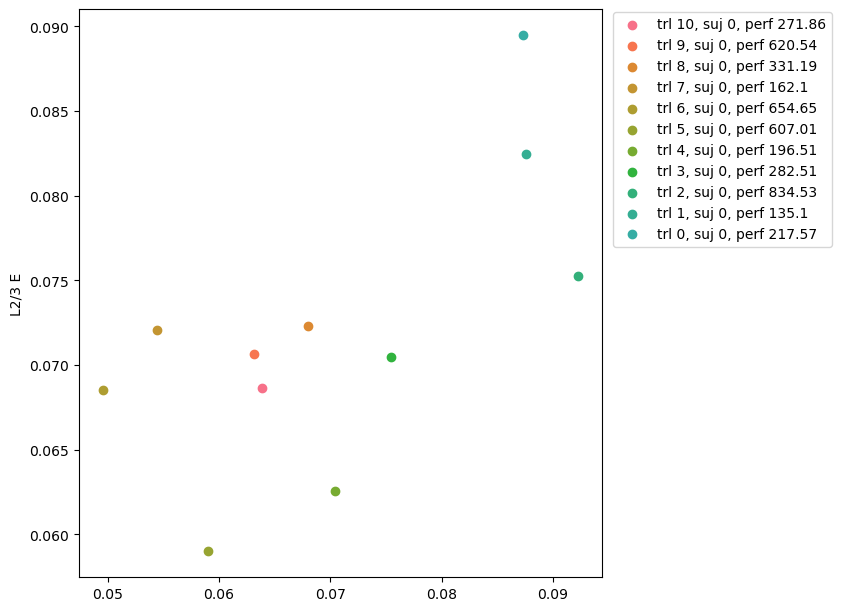

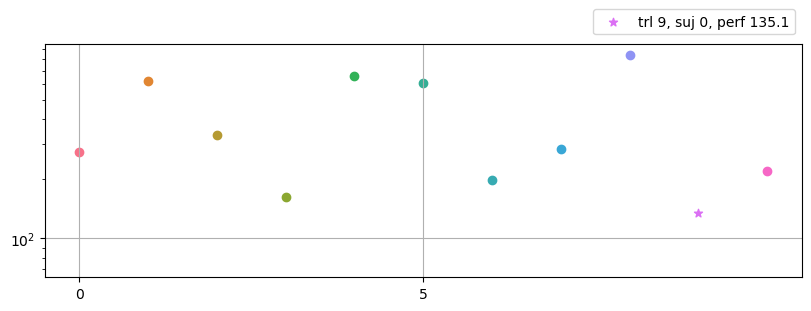

In [19]:
suj = 0

#pso.plot_best_params(folder_path, 'sub')
pso.plot_best_params(folder_path, 'all')

#pso.plot_params(folder_path, 99,-1)
#pso.plot_performance(folder_path, -1, -1, -1)

pso.plot_params_2_var(folder_path, -1, suj, [0, 1], 10)
pso.plot_performance(folder_path, -1, suj, -1)
#pso.plot_params(folder_path, -1, suj)

#pso.plot_activity(folder_path, -1, -1, -10)
plt.show()

In [7]:
pso.modify_performance(folder_path)
#pso.save_result(folder_path, os.path.join(folder_path,'20240821020030'), 0, 0)


In [14]:
## intento de merge de las bases de datos
    
# Results
cols = np.array(['trials', 'subjects'])
params = range(5)
names = np.concatenate((cols, params), axis=None)

df0 = pd.read_csv(os.path.join(folder_path, 'results0.csv'), header=None, names=names)
df1 = pd.read_csv(os.path.join(folder_path, 'results1.csv'), header=None, names=names)
m = df0.columns.to_list()

trial = df0['trials'].unique()
subject = df0['subjects'].unique()

for j, trl in enumerate(trial):
    for i, suj in enumerate(subject):

        activity = df0[(df0['trials']==trl) & (df0['subjects']==suj)][m[2:]].values[0]
        n_df = pd.DataFrame([np.concatenate(([trl, suj], activity), axis=None)])

        n_df.to_csv(os.path.join(folder_path, 'results_mod.csv'), mode='a', index=False, header=False)

    for i, suj in enumerate(subject):

        activity = df1[(df1['trials']==trl) & (df1['subjects']==suj)][m[2:]].values[0]
        n_df = pd.DataFrame([np.concatenate(([trl, suj+10], activity), axis=None)])

        n_df.to_csv(os.path.join(folder_path, 'results_mod.csv'), mode='a', index=False, header=False)


# Swarm
cols = np.array(['trials', 'subjects'])
params = range(24)
names = np.concatenate((cols, params), axis=None)

df0 = pd.read_csv(os.path.join(folder_path, 'swarm0.csv'), header=None, names=names)
df1 = pd.read_csv(os.path.join(folder_path, 'swarm1.csv'), header=None, names=names)
m = df0.columns.to_list()

trial = df0['trials'].unique()
subject = df0['subjects'].unique()

for j, trl in enumerate(trial):
    for i, suj in enumerate(subject):

        params = df0[(df0['trials']==trl) & (df0['subjects']==suj)][m[2:]].values[0]
        n_df = pd.DataFrame([np.concatenate(([trl, suj], params), axis=None)])

        n_df.to_csv(os.path.join(folder_path, 'swarm_mod.csv'), mode='a', index=False, header=False)

    for i, suj in enumerate(subject):

        params = df1[(df1['trials']==trl) & (df1['subjects']==suj)][m[2:]].values[0]
        n_df = pd.DataFrame([np.concatenate(([trl, suj+10], params), axis=None)])

        n_df.to_csv(os.path.join(folder_path, 'swarm_mod.csv'), mode='a', index=False, header=False)
